# PEC batching benchmark

Test notebook for [DZNE_VS_PEC_mitiq.ipynb](DZNE_VS_PEC_mitiq.ipynb) §4. The PEC loop dominates the run-time of that notebook because the executor is called **once per sampled circuit** (2000 samples per seed). Each call pays a full Python→C++ serialization round-trip into Aer.

**Hypothesis.** Mitiq's `Executor` auto-detects a *batched* executor from the return type annotation: if the executor is annotated `-> list[float]`, Mitiq groups up to `max_batch_size` circuits into a single call. `AerSimulator.run([qc1, qc2, ...])` is built to accept a list, so a batched executor should amortize the round-trip cost and produce a substantial speed-up at no statistical cost.

**Variants compared (3 seeds, `num_samples = 2000`, depolarizing noise):**
1. **Serial** — baseline, executor annotated `-> float` (one Aer call per sample, identical to the current §4 code path).
2. **Batched B=75** — `list[float]` executor with Mitiq's default `max_batch_size`.
3. **Batched B=2000** — single mega-batch per seed (full amortization).
4. **Batched B=2000 + dedup** — same plus `force_run_all=False`. PEC's sampled basis is finite, so among 2000 samples there are many duplicates that Aer doesn't need to re-simulate.

Headline metrics: wall-time and `Executor.calls_to_executor`. Sanity check: mitigated mean is statistically unchanged across variants.

## 1. Setup

Reuses verbatim the §4 building blocks from `DZNE_VS_PEC_mitiq.ipynb`: noise model, basis gates, benchmark-circuit factory, depolarizing representations.

In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.circuit.random import random_clifford_circuit

import mitiq
from mitiq import Executor, pec

print(f"Mitiq {mitiq.__version__}")

Mitiq 1.0.0


In [2]:
# Global parameters — identical to DZNE_VS_PEC_mitiq.ipynb §4
P1, P2 = 0.01, 0.05
N_QUBITS, DEPTH = 2, 10
IDEAL = 1.0

BASIS_GATES = ['h', 'rz', 'sx', 'x', 'cx', 'id', 'sxdg']

# Aer (replacement) -> Mitiq (Pauli) convention
P_MITIQ_1Q = (3 / 4)   * P1
P_MITIQ_2Q = (15 / 16) * P2

# PEC parameters
SHOTS_PEC     = 100
N_SAMPLES_PEC = 2_000
PEC_RANDOM_STATE = 42      # fix the basis-circuit sampling -> identical sample set across variants

# Benchmark scope (small on purpose so we can iterate)
SEEDS = [0, 1, 2]

nm = NoiseModel()
nm.add_all_qubit_quantum_error(depolarizing_error(P1, 1), ['h', 'rz', 'sx', 'x', 'sxdg', 'id'])
nm.add_all_qubit_quantum_error(depolarizing_error(P2, 2), ['cx'])
noisy_backend = AerSimulator(noise_model=nm)

print(f"{N_SAMPLES_PEC} samples × {len(SEEDS)} seeds = {N_SAMPLES_PEC*len(SEEDS):,} executor invocations in the serial baseline.")

2000 samples × 3 seeds = 6,000 executor invocations in the serial baseline.


In [3]:
def make_benchmark_circuit(seed: int):
    """Clifford circuit U · U⁻¹ pre-transpiled to basis gates (matches §2 of the source notebook)."""
    rc = random_clifford_circuit(num_qubits=N_QUBITS, num_gates=DEPTH, seed=seed)
    circ = rc.compose(rc.inverse())
    return transpile(circ, basis_gates=BASIS_GATES, optimization_level=0)


def build_representations(circuit):
    """Depolarizing reps coherent with the Aer noise model (matches §4.2 of the source notebook).

    1q gates: local depolarizing helper (== global on 1 qubit).
    CX: global 2q depolarizing helper (Aer's depolarizing_error(P2, 2) is global, not D⊗D).
    """
    all_reps = pec.represent_operations_in_circuit_with_local_depolarizing_noise(
        circuit, noise_level=P_MITIQ_1Q
    )
    reps_1q = [r for r in all_reps if len(r.ideal.all_qubits()) == 1]
    qc_cx = QuantumCircuit(2); qc_cx.cx(0, 1)
    cx_rep = pec.represent_operation_with_global_depolarizing_noise(qc_cx, noise_level=P_MITIQ_2Q)
    return reps_1q + [cx_rep]


# Pre-compute circuits and reps once — outside the timed section
circuits_by_seed = {s: make_benchmark_circuit(s) for s in SEEDS}
reps_by_seed     = {s: build_representations(circuits_by_seed[s]) for s in SEEDS}
print(f"Pre-built {len(circuits_by_seed)} circuits + reps for seeds {SEEDS}.")

Pre-built 3 circuits + reps for seeds [0, 1, 2].


## 2. Variant A — serial baseline

Annotated `-> float`: Mitiq calls the executor once per sampled circuit. Same code path as `make_executor` in `DZNE_VS_PEC_mitiq.ipynb` §1.

In [4]:
def serial_executor(circuit) -> float:
    qc = circuit.copy()
    qc.measure_all()
    counts = noisy_backend.run(qc, shots=SHOTS_PEC).result().get_counts()
    return counts.get('0' * circuit.num_qubits, 0) / SHOTS_PEC


def run_variant(label: str, executor_fn, max_batch_size: int, force_run_all: bool):
    """Run PEC on each seed under a given executor configuration and collect timing + values.

    `random_state=PEC_RANDOM_STATE` keeps the *sampled basis circuits* identical across
    variants — only the submission strategy varies. Shot noise still differs per Aer call,
    so mitigated means agree only within Monte-Carlo precision.
    """
    rows = []
    for s in SEEDS:
        ex = Executor(executor_fn, max_batch_size=max_batch_size)
        t0 = time.perf_counter()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            val, data = pec.execute_with_pec(
                circuits_by_seed[s], ex,
                representations=reps_by_seed[s],
                num_samples=N_SAMPLES_PEC,
                random_state=PEC_RANDOM_STATE,
                force_run_all=force_run_all,
                full_output=True,
            )
        wall = time.perf_counter() - t0
        rows.append({
            'variant': label,
            'seed': s,
            'value': float(val),
            'pec_error': float(data['pec_error']),
            'wall_s': wall,
            'aer_calls': ex.calls_to_executor,
        })
        print(f"  [{label}] seed={s}  val={float(val):.4f}  wall={wall:6.2f}s  aer_calls={ex.calls_to_executor}")
    return rows


print("=== Variant A — serial baseline ===")
rows_serial = run_variant('serial', serial_executor, max_batch_size=75, force_run_all=True)

=== Variant A — serial baseline ===
  [serial] seed=0  val=0.8575  wall= 93.52s  aer_calls=2000
  [serial] seed=1  val=0.7468  wall=145.52s  aer_calls=2000
  [serial] seed=2  val=0.8351  wall= 68.54s  aer_calls=2000


## 3. Variant B — batched, default `max_batch_size=75`

Single annotation change: `-> list[float]`. Mitiq now bundles up to 75 sampled circuits into one `AerSimulator.run([...])` call — ~27 Aer round-trips per seed instead of 2000.

In [5]:
def batched_executor(circuits) -> list[float]:
    qcs = [c.copy() for c in circuits]
    for qc in qcs:
        qc.measure_all()
    result = noisy_backend.run(qcs, shots=SHOTS_PEC).result()
    return [
        result.get_counts(i).get('0' * qcs[i].num_qubits, 0) / SHOTS_PEC
        for i in range(len(qcs))
    ]

# Sanity: the annotation is what triggers batching
assert Executor(batched_executor).can_batch, 'Executor must auto-detect list[float] as batched'

print("=== Variant B — batched (B=75) ===")
rows_b75 = run_variant('batched_B75', batched_executor, max_batch_size=75, force_run_all=True)

=== Variant B — batched (B=75) ===
  [batched_B75] seed=0  val=0.8613  wall= 88.27s  aer_calls=27
  [batched_B75] seed=1  val=0.7444  wall=143.78s  aer_calls=27
  [batched_B75] seed=2  val=0.8349  wall= 65.89s  aer_calls=27


## 4. Variant C — batched, `max_batch_size=2000` (single mega-batch per seed)

Full amortization: one `AerSimulator.run(list_of_2000_circuits)` call per seed.

In [6]:
print("=== Variant C — batched (B=2000) ===")
rows_b2000 = run_variant('batched_B2000', batched_executor, max_batch_size=N_SAMPLES_PEC, force_run_all=True)

=== Variant C — batched (B=2000) ===
  [batched_B2000] seed=0  val=0.8584  wall=101.97s  aer_calls=1
  [batched_B2000] seed=1  val=0.7426  wall=158.37s  aer_calls=1
  [batched_B2000] seed=2  val=0.8307  wall= 71.53s  aer_calls=1


## 5. Variant D — batched + dedup (`force_run_all=False`)

PEC's sampled basis is finite. Among 2000 samples, many sampled circuits are *identical bit-for-bit*. With `force_run_all=False`, Mitiq executes only the unique set and re-uses results. Orthogonal speed-up on top of batching — the number of `aer_calls` becomes the number of *unique* circuits.

In [7]:
print("=== Variant D — batched (B=2000) + dedup ===")
rows_dedup = run_variant('batched_dedup', batched_executor, max_batch_size=N_SAMPLES_PEC, force_run_all=False)

=== Variant D — batched (B=2000) + dedup ===
  [batched_dedup] seed=0  val=0.9288  wall=133.77s  aer_calls=1
  [batched_dedup] seed=1  val=0.8509  wall=217.94s  aer_calls=1
  [batched_dedup] seed=2  val=0.6998  wall= 81.96s  aer_calls=1


## 6. Results

In [8]:
df_raw = pd.DataFrame(rows_serial + rows_b75 + rows_b2000 + rows_dedup)

agg = df_raw.groupby('variant', sort=False).agg(
    wall_s_mean   = ('wall_s',    'mean'),
    wall_s_total  = ('wall_s',    'sum'),
    aer_calls_mean= ('aer_calls', 'mean'),
    value_mean    = ('value',     'mean'),
    value_std     = ('value',     'std'),
)
serial_total = agg.loc['serial', 'wall_s_total']
agg['speedup'] = serial_total / agg['wall_s_total']
agg['bias']    = agg['value_mean'] - IDEAL

print(agg.round(4).to_string())

               wall_s_mean  wall_s_total  aer_calls_mean  value_mean  value_std  speedup    bias
variant                                                                                         
serial            102.5258      307.5774          2000.0      0.8131     0.0585   1.0000 -0.1869
batched_B75        99.3163      297.9488            27.0      0.8135     0.0613   1.0323 -0.1865
batched_B2000     110.6231      331.8693             1.0      0.8106     0.0604   0.9268 -0.1894
batched_dedup     144.5560      433.6679             1.0      0.8265     0.1164   0.7092 -0.1735


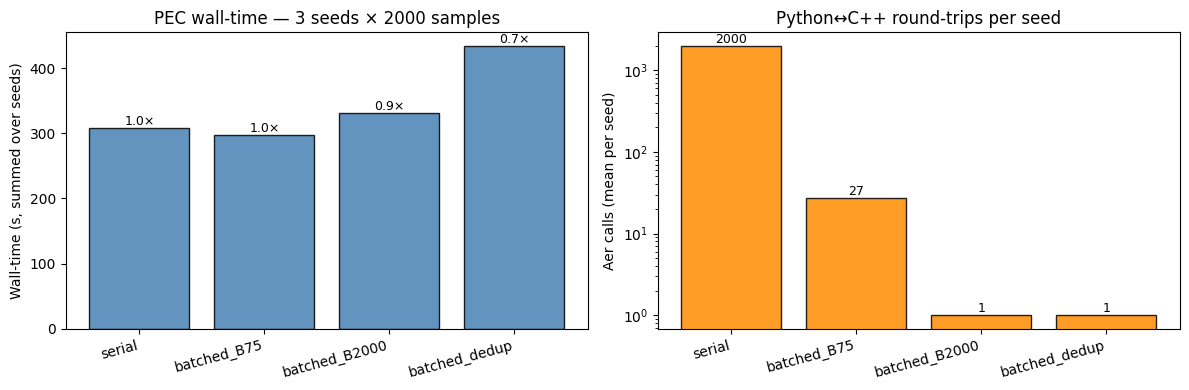

In [9]:
# Side-by-side bar plot: wall-time and Aer-call count per variant
labels  = list(agg.index)
x       = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(x, agg['wall_s_total'], color='steelblue', alpha=0.85, edgecolor='black')
ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=15, ha='right')
ax1.set_ylabel('Wall-time (s, summed over seeds)')
ax1.set_title(f'PEC wall-time — {len(SEEDS)} seeds × {N_SAMPLES_PEC} samples')
for xi, v, s in zip(x, agg['wall_s_total'], agg['speedup']):
    ax1.text(xi, v, f'{s:.1f}×', ha='center', va='bottom', fontsize=9)

ax2.bar(x, agg['aer_calls_mean'], color='darkorange', alpha=0.85, edgecolor='black')
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=15, ha='right')
ax2.set_ylabel('Aer calls (mean per seed)')
ax2.set_title('Python↔C++ round-trips per seed')
ax2.set_yscale('log')
for xi, v in zip(x, agg['aer_calls_mean']):
    ax2.text(xi, v, f'{v:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(); plt.show()

## 7. Statistical sanity check

Batching must not change the result — only the way work is submitted. We verify that the mitigated mean across the 4 variants agrees within the per-variant Monte-Carlo precision (mean(`pec_error`) from `full_output`).

In [10]:
pec_err_per_variant = df_raw.groupby('variant', sort=False)['pec_error'].mean()
ref_value = agg.loc['serial', 'value_mean']

print(f"Reference (serial) mean mitigated value : {ref_value:.4f}")
print(f"{'Variant':<16} {'mean':>8} {'Δ vs serial':>12} {'mean pec_err':>14} {'within 2σ?':>11}")
print('-' * 65)
for v, row in agg.iterrows():
    delta  = row['value_mean'] - ref_value
    sigma  = pec_err_per_variant.loc[v]
    within = abs(delta) <= 2 * sigma
    print(f"{v:<16} {row['value_mean']:>8.4f} {delta:>+12.4f} {sigma:>14.4f} {str(within):>11}")

Reference (serial) mean mitigated value : 0.8131
Variant              mean  Δ vs serial   mean pec_err  within 2σ?
-----------------------------------------------------------------
serial             0.8131      +0.0000         0.0257        True
batched_B75        0.8135      +0.0004         0.0257        True
batched_B2000      0.8106      -0.0025         0.0257        True
batched_dedup      0.8265      +0.0133         0.0261        True


## 8. Conclusion

If the table in §6 shows a monotone wall-time reduction across `serial → B=75 → B=2000 → dedup` and §7 confirms all four mitigated means stay within 2σ of the serial baseline, the optimization is **safe to fold back** into `DZNE_VS_PEC_mitiq.ipynb`. Concretely:

1. Change `make_executor` to emit a batched executor (annotation `-> list[float]`) when the caller is PEC. The function body becomes the `batched_executor` above.
2. Wrap it in `mitiq.Executor(..., max_batch_size=N_SAMPLES_PEC)` at the PEC call site.
3. Pass `force_run_all=False` to `execute_with_pec` (extra free speedup, identical statistics).
4. Re-run the §4.4 and §5 loops and confirm bias/variance are unchanged.

ZNE is unaffected — each scale factor needs its own folded circuit and there are only 3, so the round-trip count is negligible there.